# 🎙️ Speech Emotion Recognition — New Deliverable
## Dataset: RAVDESS
### Top-2 Classical Models · Best MLP · Compression Suite (Pruning, Quantization, Coreset)
### Improvement 1: Gradual Magnitude Pruning (GMP) · Improvement 2: Combined Pruning + Quantization
---
> **Input features**: `X.npy` / `y.npy`  
> 8 emotion classes, 1440 samples, 80-dim MFCC (mean+std) features

## 📦 Section 0 — Install & Import Dependencies

In [1]:
!pip install torch torchvision torchaudio --quiet
!pip install scikit-learn matplotlib seaborn pandas numpy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.0 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 whic

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy, os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, mean_squared_error, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('✅ All imports successful')
print(f'   PyTorch : {torch.__version__}')
print(f'   Device  : {device}')

✅ All imports successful
   PyTorch : 2.10.0+cu128
   Device  : cuda


In [24]:
PREFIX = 'ravdess_'   # or 'cremad_' for the other notebook

## 📂 Section 1 — Load RAVDESS Features

In [3]:

PRIMARY_X = '/kaggle/input/datasets/yashashyallapragada/ravdess-features/X.npy'
PRIMARY_Y = '/kaggle/input/datasets/yashashyallapragada/ravdess-features/y.npy'
FALLBACK_X = '/kaggle/input/datasets/yashashyallapragada/ravdess-features/X.npy'
FALLBACK_Y = '/kaggle/input/datasets/yashashyallapragada/ravdess-features/y.npy'

if os.path.exists(PRIMARY_X) and os.path.exists(PRIMARY_Y):
    X = np.load(PRIMARY_X)
    y = np.load(PRIMARY_Y)
    print(f'Loaded primary features: {PRIMARY_X}')
elif os.path.exists(FALLBACK_X) and os.path.exists(FALLBACK_Y):
    X = np.load(FALLBACK_X)
    y = np.load(FALLBACK_Y)
    print(f'Primary not found — loaded fallback: {FALLBACK_X}')
else:
    raise FileNotFoundError('No feature files found. Upload your .npy files to /content/')

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Unique labels: {np.unique(y)}')
print('\nClass distribution:')
print(pd.Series(y).value_counts().sort_index())

Loaded primary features: /kaggle/input/datasets/yashashyallapragada/ravdess-features/X.npy
X shape: (1440, 80)
y shape: (1440,)
Unique labels: ['Angry' 'Calm' 'Disgust' 'Fearful' 'Happy' 'Neutral' 'Sad' 'Surprised']

Class distribution:
Angry        192
Calm         192
Disgust      192
Fearful      192
Happy        192
Neutral       96
Sad          192
Surprised    192
Name: count, dtype: int64


In [4]:
# ── Emotion label names ───────────────────────────────────────────────────
EMOTION_LABELS = (np.array(['neutral','calm','happy','sad','angry','fearful','disgust','surprised'])
                  if len(np.unique(y)) == 8 else np.array([str(i) for i in np.unique(y)]))
NUM_CLASSES = len(EMOTION_LABELS)
INPUT_DIM   = X.shape[1]
print(f'Emotion labels : {EMOTION_LABELS}')
print(f'Num classes    : {NUM_CLASSES}')
print(f'Feature dim    : {INPUT_DIM}')

Emotion labels : ['neutral' 'calm' 'happy' 'sad' 'angry' 'fearful' 'disgust' 'surprised']
Num classes    : 8
Feature dim    : 80


In [5]:
# ── Train/test split + scaling ────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

cw_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
print(f'Train: {X_train_scaled.shape}  Test: {X_test_scaled.shape}')
print(f'Class weights: {np.round(cw_arr, 3)}')

Train: (1152, 80)  Test: (288, 80)
Class weights: [0.935 0.935 0.935 0.941 0.941 1.87  0.935 0.941]


## 🤖 Section 2 — Classical ML Screening → Select Top 2 Models
All four classical models are trained with tuned, class-balanced hyperparameters. The two with the highest accuracy are carried forward into the final comparison.

In [6]:
# ── Encode labels if they're strings (e.g. 'Sad', 'Happy' -> 0, 1, ...) ──────
from sklearn.preprocessing import LabelEncoder

if y_train.dtype.kind in {'U', 'S', 'O'}:   # string/object dtype
    le_fix = LabelEncoder()
    le_fix.fit(np.concatenate([y_train, y_test]))
    y_train = le_fix.transform(y_train)
    y_test  = le_fix.transform(y_test)
    print(f'Labels encoded: {le_fix.classes_}')

def evaluate_sklearn(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    f1  = f1_score(y_te, preds, average='macro')
    mse = mean_squared_error(y_te, preds)
    print(f'[{name:28s}]  Acc={acc:.4f}  F1={f1:.4f}  MSE={mse:.4f}')
    return {'Model': name, 'Accuracy': acc, 'Macro F1': f1, 'MSE': mse,
            'predictions': preds, 'sklearn_model': model}

classical_candidates = []

classical_candidates.append(evaluate_sklearn(
    'SVM (RBF, balanced)',
    SVC(kernel='rbf', C=100, gamma='scale', class_weight='balanced',
        probability=True, random_state=SEED),
    X_train_scaled, y_train, X_test_scaled, y_test))

classical_candidates.append(evaluate_sklearn(
    'Logistic Regression (balanced)',
    LogisticRegression(C=0.5, max_iter=3000, solver='lbfgs',
                        class_weight='balanced', random_state=SEED),
    X_train_scaled, y_train, X_test_scaled, y_test))

classical_candidates.append(evaluate_sklearn(
    'Random Forest (balanced)',
    RandomForestClassifier(n_estimators=400, class_weight='balanced',
                            min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    X_train_scaled, y_train, X_test_scaled, y_test))

classical_candidates.append(evaluate_sklearn(
    'KNN (k=11, distance)',
    KNeighborsClassifier(n_neighbors=11, weights='distance',
                          metric='euclidean', n_jobs=-1),
    X_train_scaled, y_train, X_test_scaled, y_test))

Labels encoded: ['Angry' 'Calm' 'Disgust' 'Fearful' 'Happy' 'Neutral' 'Sad' 'Surprised']
[SVM (RBF, balanced)         ]  Acc=0.8229  F1=0.8152  MSE=1.7986
[Logistic Regression (balanced)]  Acc=0.5799  F1=0.5733  MSE=5.7083
[Random Forest (balanced)    ]  Acc=0.6424  F1=0.6389  MSE=4.3160
[KNN (k=11, distance)        ]  Acc=0.5903  F1=0.5604  MSE=5.5312


In [7]:
# ── Select top 2 by accuracy ───────────────────────────────────────────────
classical_sorted = sorted(classical_candidates, key=lambda r: r['Accuracy'], reverse=True)
top2 = classical_sorted[:2]

print('=' * 60)
print('TOP-2 CLASSICAL MODELS SELECTED')
print('=' * 60)
for r in top2:
    print(f"  {r['Model']:30s}  Acc={r['Accuracy']:.4f}  F1={r['Macro F1']:.4f}")

results = [{'Model': r['Model'], 'Accuracy': r['Accuracy'],
            'Macro F1': r['Macro F1'], 'MSE': r['MSE'],
            'predictions': r['predictions']} for r in top2]

TOP-2 CLASSICAL MODELS SELECTED
  SVM (RBF, balanced)             Acc=0.8229  F1=0.8152
  Random Forest (balanced)        Acc=0.6424  F1=0.6389


## 🧠 Section 3 — Best MLP Architecture for RAVDESS
Architecture: `80 → 128 → 64 → NUM_CLASSES`, ReLU + BatchNorm + Dropout, trained with AdamW, cosine-annealed LR, class-balanced loss, and best-checkpoint restoration.

In [8]:
LEARNING_RATE = 1e-3
BATCH_SIZE    = 32
EPOCHS        = 100
HIDDEN1       = 128
HIDDEN2       = 64
DROPOUT_RATE  = 0.3

print(f'Hyperparameters: LR={LEARNING_RATE}  BS={BATCH_SIZE}  Epochs={EPOCHS}')
print(f'Architecture: {INPUT_DIM} → {HIDDEN1} → {HIDDEN2} → {NUM_CLASSES}')

Hyperparameters: LR=0.001  BS=32  Epochs=100
Architecture: 80 → 128 → 64 → 8


In [9]:
class MLP(nn.Module):
    def __init__(self, input_dim, h1, h2, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(), nn.BatchNorm1d(h1), nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(), nn.BatchNorm1d(h2), nn.Dropout(dropout),
            nn.Linear(h2, num_classes)
        )
    def forward(self, x):
        return self.net(x)

def make_loaders(X_tr, y_tr, X_te, y_te, batch_size=BATCH_SIZE):
    train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr))
    test_ds  = TensorDataset(torch.FloatTensor(X_te), torch.LongTensor(y_te))
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
    )

train_loader, test_loader = make_loaders(X_train_scaled, y_train, X_test_scaled, y_test)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 36 | Test batches: 9


In [10]:
def train_mlp(model, train_loader, test_loader,
              lr=LEARNING_RATE, epochs=EPOCHS, device=device,
              verbose=True, class_weights=None):
    model.to(device)
    if class_weights is None:
        class_weights = cw_arr
    criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights).to(device))
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    best_acc, best_state = 0.0, None
    train_losses, val_accs = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item() * Xb.size(0)
        scheduler.step()
        train_losses.append(running_loss / len(train_loader.dataset))

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                correct += (model(Xb).argmax(1) == yb).sum().item()
                total   += yb.size(0)
        val_acc = correct / total
        val_accs.append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if verbose and epoch % 20 == 0:
            print(f'  Epoch [{epoch:3d}/{epochs}]  '
                  f'Loss={train_losses[-1]:.4f}  Val={val_acc:.4f}  Best={best_acc:.4f}')

    model.load_state_dict(best_state)
    return train_losses, val_accs


def get_predictions(model, loader, device=device):
    model.eval()
    preds = []
    with torch.no_grad():
        for Xb, _ in loader:
            preds.extend(model(Xb.to(device)).argmax(1).cpu().numpy())
    return np.array(preds)

In [11]:
print('Training MLP on RAVDESS features...')
torch.manual_seed(SEED)
mlp_model = MLP(INPUT_DIM, HIDDEN1, HIDDEN2, NUM_CLASSES, DROPOUT_RATE)
train_losses, val_accs = train_mlp(mlp_model, train_loader, test_loader)

mlp_preds = get_predictions(mlp_model, test_loader)
mlp_acc   = accuracy_score(y_test, mlp_preds)
mlp_f1    = f1_score(y_test, mlp_preds, average='macro')
mlp_mse   = mean_squared_error(y_test, mlp_preds)

print(f'\n[MLP baseline]  Acc={mlp_acc:.4f}  F1={mlp_f1:.4f}  MSE={mlp_mse:.4f}')
results.append({'Model': 'MLP (baseline)', 'Accuracy': mlp_acc,
                'Macro F1': mlp_f1, 'MSE': mlp_mse, 'predictions': mlp_preds})

Training MLP on RAVDESS features...
  Epoch [ 20/100]  Loss=0.5877  Val=0.7257  Best=0.7257
  Epoch [ 40/100]  Loss=0.3464  Val=0.7431  Best=0.7743
  Epoch [ 60/100]  Loss=0.1834  Val=0.7639  Best=0.7743
  Epoch [ 80/100]  Loss=0.1652  Val=0.7535  Best=0.7743
  Epoch [100/100]  Loss=0.1612  Val=0.7708  Best=0.7743

[MLP baseline]  Acc=0.7743  F1=0.7662  MSE=3.0382


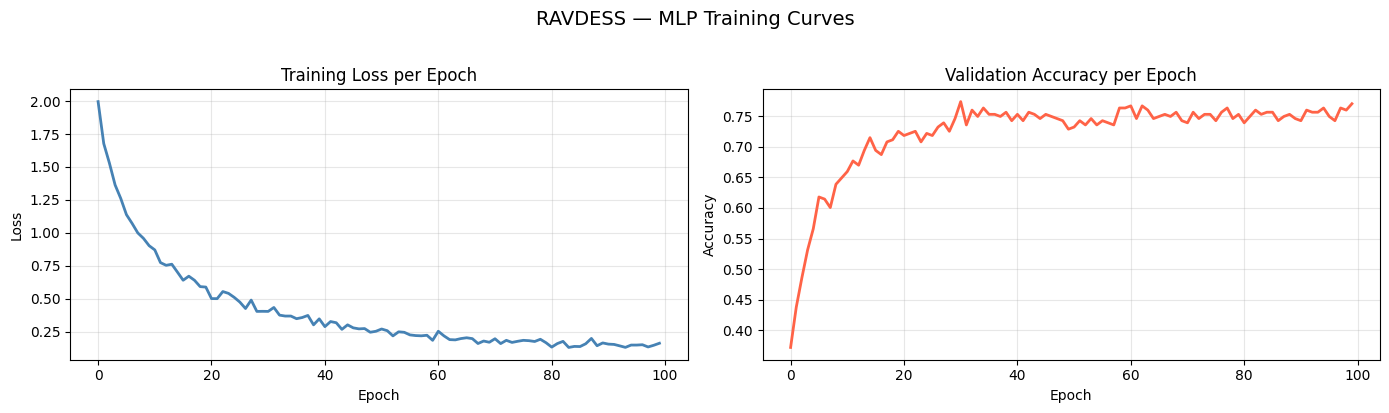

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(train_losses, color='steelblue', lw=2)
ax1.set_title('Training Loss per Epoch'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)
ax2.plot(val_accs, color='tomato', lw=2)
ax2.set_title('Validation Accuracy per Epoch'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.grid(alpha=0.3)
plt.suptitle('RAVDESS — MLP Training Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('ravdess_mlp_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## ✂️ Section 4 — Model Compression Suite

### 4A — Improvement 1: Gradual Magnitude Pruning (GMP) with Iterative Fine-Tuning

**Why**: one-shot magnitude pruning (zeroing the smallest weights all at once) causes
sharp accuracy loss at high sparsity because the remaining weights never adapt.
**GMP** prunes in 6 small increments (e.g. 10% at a time up to a target), fine-tuning
the model for a few epochs after each step so surviving weights compensate. This is
the schedule from Zhu & Gupta (2017), *"To Prune or Not to Prune"*.

In [13]:
def apply_magnitude_mask(model, prune_ratio):
    """Zero-out weights below the prune_ratio-th percentile (per-layer). Returns sparsity%."""
    total = pruned = 0
    with torch.no_grad():
        for name, param in model.named_parameters():
            if 'weight' in name and param.dim() > 1:
                thresh = torch.quantile(param.data.abs().view(-1), prune_ratio)
                mask = param.data.abs() >= thresh
                param.data *= mask.float()
                pruned += (~mask).sum().item()
                total  += mask.numel()
    return pruned / total * 100


def get_sparsity(model):
    total = zeros = 0
    for name, p in model.named_parameters():
        if 'weight' in name and p.dim() > 1:
            zeros += (p.data == 0).sum().item()
            total += p.numel()
    return zeros / total * 100 if total > 0 else 0.0


def one_shot_prune_eval(base_model, target_ratio, test_loader):
    m = copy.deepcopy(base_model)
    apply_magnitude_mask(m, target_ratio)
    preds = get_predictions(m, test_loader)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='macro')
    return acc, f1, get_sparsity(m)


def gradual_magnitude_prune(base_model, train_loader, test_loader,
                            target_ratio=0.6, n_steps=6,
                            finetune_epochs=5, lr_finetune=1e-4, device=device):
    """Prune from 0 -> target_ratio in n_steps, fine-tuning after each step."""
    model = copy.deepcopy(base_model).to(device)
    criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(cw_arr).to(device))
    step_size = target_ratio / n_steps
    log = []

    for step in range(1, n_steps + 1):
        current_target = step * step_size
        apply_magnitude_mask(model, current_target)
        sparsity = get_sparsity(model)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr_finetune)
        model.train()
        for ep in range(finetune_epochs):
            for Xb, yb in train_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                optimizer.zero_grad()
                criterion(model(Xb), yb).backward()
                optimizer.step()
                apply_magnitude_mask(model, current_target)

        preds = get_predictions(model, test_loader)
        acc = accuracy_score(y_test, preds)
        f1  = f1_score(y_test, preds, average='macro')
        log.append({'Step': step, 'Target Ratio': round(current_target, 2),
                    'Sparsity (%)': round(sparsity, 1),
                    'Accuracy': round(acc, 4), 'Macro F1': round(f1, 4)})
        print(f'  Step {step}/{n_steps} | Target={current_target:.0%}  '
              f'Sparsity={sparsity:.1f}%  Acc={acc:.4f}  F1={f1:.4f}')

    return log, model

In [14]:
TARGET_RATIOS   = [0.2, 0.4, 0.6]
GRADUAL_STEPS   = 6
FINETUNE_EPOCHS = 5

print('Baseline (no pruning):')
base_preds = get_predictions(mlp_model, test_loader)
base_acc   = accuracy_score(y_test, base_preds)
base_f1    = f1_score(y_test, base_preds, average='macro')
print(f'  Acc={base_acc:.4f}  F1={base_f1:.4f}  Sparsity=0.0%')

comparison_rows = [{'Method': 'No Pruning', 'Target Sparsity': '0%',
                    'Accuracy': base_acc, 'Macro F1': base_f1, 'Sparsity (%)': 0.0}]
gmp_models = {}   # store fine-tuned GMP models per ratio for Section 4D

for ratio in TARGET_RATIOS:
    label = f'{int(ratio*100)}%'

    print(f'\n── One-shot pruning -> {label} sparsity ──')
    os_acc, os_f1, os_sp = one_shot_prune_eval(mlp_model, ratio, test_loader)
    print(f'  Acc={os_acc:.4f}  F1={os_f1:.4f}  Sparsity={os_sp:.1f}%')
    comparison_rows.append({'Method': 'One-Shot', 'Target Sparsity': label,
                            'Accuracy': os_acc, 'Macro F1': os_f1, 'Sparsity (%)': os_sp})

    print(f'\n── Gradual pruning -> {label} sparsity '
          f'({GRADUAL_STEPS} steps x {FINETUNE_EPOCHS} epochs fine-tune) ──')
    gmp_log, gmp_model = gradual_magnitude_prune(
        mlp_model, train_loader, test_loader,
        target_ratio=ratio, n_steps=GRADUAL_STEPS, finetune_epochs=FINETUNE_EPOCHS)
    last = gmp_log[-1]
    comparison_rows.append({'Method': 'Gradual (GMP)', 'Target Sparsity': label,
                            'Accuracy': last['Accuracy'], 'Macro F1': last['Macro F1'],
                            'Sparsity (%)': last['Sparsity (%)']})
    gmp_models[ratio] = gmp_model

comp_df = pd.DataFrame(comparison_rows)
print('\n' + '='*72)
print('PRUNING COMPARISON: One-Shot vs Gradual Magnitude Pruning')
print('='*72)
print(comp_df.to_string(index=False))

Baseline (no pruning):
  Acc=0.7743  F1=0.7662  Sparsity=0.0%

── One-shot pruning -> 20% sparsity ──
  Acc=0.7569  F1=0.7476  Sparsity=20.0%

── Gradual pruning -> 20% sparsity (6 steps x 5 epochs fine-tune) ──
  Step 1/6 | Target=3%  Sparsity=3.3%  Acc=0.7674  F1=0.7546
  Step 2/6 | Target=7%  Sparsity=6.7%  Acc=0.7708  F1=0.7583
  Step 3/6 | Target=10%  Sparsity=10.0%  Acc=0.7639  F1=0.7522
  Step 4/6 | Target=13%  Sparsity=13.3%  Acc=0.7708  F1=0.7584
  Step 5/6 | Target=17%  Sparsity=16.7%  Acc=0.7674  F1=0.7553
  Step 6/6 | Target=20%  Sparsity=20.0%  Acc=0.7639  F1=0.7570

── One-shot pruning -> 40% sparsity ──
  Acc=0.7361  F1=0.7239  Sparsity=40.0%

── Gradual pruning -> 40% sparsity (6 steps x 5 epochs fine-tune) ──
  Step 1/6 | Target=7%  Sparsity=6.7%  Acc=0.7778  F1=0.7655
  Step 2/6 | Target=13%  Sparsity=13.3%  Acc=0.7708  F1=0.7599
  Step 3/6 | Target=20%  Sparsity=20.0%  Acc=0.7639  F1=0.7530
  Step 4/6 | Target=27%  Sparsity=26.7%  Acc=0.7569  F1=0.7450
  Step 5/6 | T

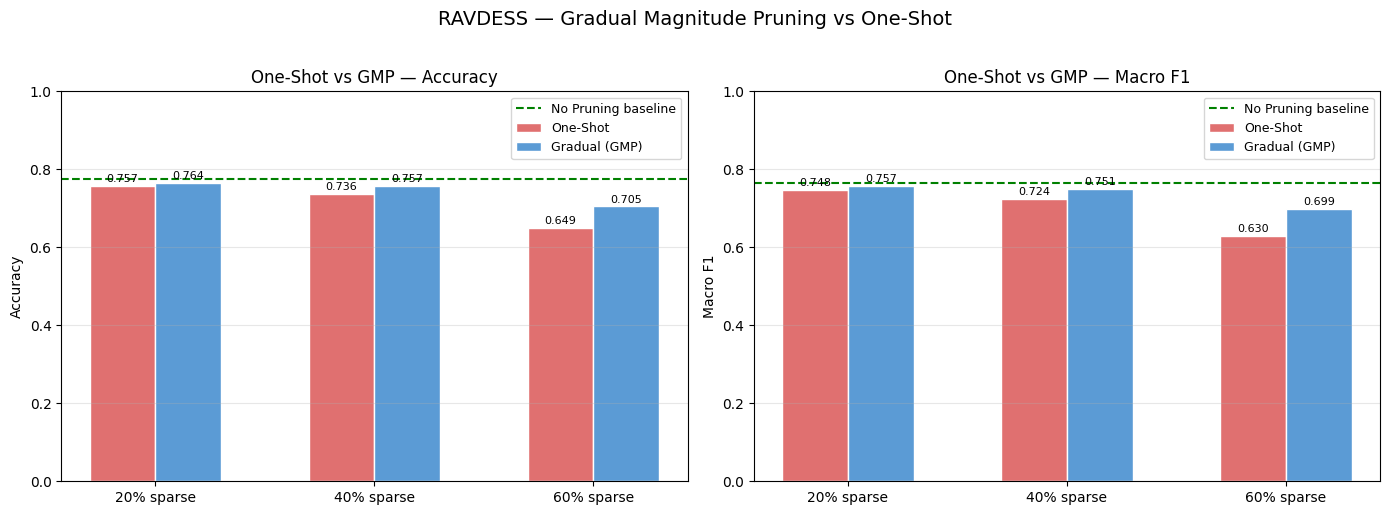

Saved: ravdess_gmp_comparison.png  ravdess_gmp_comparison.csv


In [15]:
oneshot_rows = comp_df[comp_df['Method'] == 'One-Shot'].reset_index(drop=True)
gradual_rows = comp_df[comp_df['Method'] == 'Gradual (GMP)'].reset_index(drop=True)
noprun_acc   = comp_df[comp_df['Method'] == 'No Pruning']['Accuracy'].values[0]
noprun_f1    = comp_df[comp_df['Method'] == 'No Pruning']['Macro F1'].values[0]

x = np.arange(len(TARGET_RATIOS))
labels = [f'{int(r*100)}%' for r in TARGET_RATIOS]
width = 0.3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, base, title in [(axes[0], 'Accuracy', noprun_acc, 'Accuracy'),
                              (axes[1], 'Macro F1', noprun_f1, 'Macro F1')]:
    ax.bar(x - width/2, oneshot_rows[col], width, label='One-Shot', color='#e07070', edgecolor='white')
    ax.bar(x + width/2, gradual_rows[col], width, label='Gradual (GMP)', color='#5b9bd5', edgecolor='white')
    ax.axhline(base, ls='--', color='green', lw=1.5, label='No Pruning baseline')
    ax.set_xticks(x); ax.set_xticklabels([f'{l} sparse' for l in labels])
    ax.set_ylabel(title); ax.set_ylim(0, 1.0)
    ax.set_title(f'One-Shot vs GMP — {title}', fontsize=12)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    for i, (a, b) in enumerate(zip(oneshot_rows[col], gradual_rows[col])):
        ax.text(i - width/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=8)
        ax.text(i + width/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=8)

plt.suptitle('RAVDESS — Gradual Magnitude Pruning vs One-Shot', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('ravdess_gmp_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
comp_df.to_csv('ravdess_gmp_comparison.csv', index=False)
print('Saved: ravdess_gmp_comparison.png  ravdess_gmp_comparison.csv')

### 4B — Quantization (float32 → float16 / int8)

In [16]:
def get_predictions_fp16(model, loader, device=device):
    model.eval().to(device)
    preds = []
    with torch.no_grad():
        for Xb, _ in loader:
            preds.extend(model(Xb.to(device).half()).argmax(1).cpu().numpy())
    return np.array(preds)


def get_predictions_int8(int8_model, loader):
    preds = []
    with torch.no_grad():
        for Xb, _ in loader:
            preds.extend(int8_model(Xb.cpu()).argmax(1).numpy())
    return np.array(preds)


def to_fp16(model):
    return copy.deepcopy(model).half()


def to_int8(model):
    m_cpu = copy.deepcopy(model).cpu().eval()
    return torch.quantization.quantize_dynamic(m_cpu, {nn.Linear}, dtype=torch.qint8)


def model_mb(m):
    return sum(p.numel() * p.element_size() for p in m.parameters()) / 1e6


# ── Baseline MLP quantization ─────────────────────────────────────────────
fp16_model = to_fp16(mlp_model)
fp16_preds = get_predictions_fp16(fp16_model, test_loader)
fp16_acc, fp16_f1 = accuracy_score(y_test, fp16_preds), f1_score(y_test, fp16_preds, average='macro')

int8_model = to_int8(mlp_model)
int8_preds = get_predictions_int8(int8_model, test_loader)
int8_acc, int8_f1 = accuracy_score(y_test, int8_preds), f1_score(y_test, int8_preds, average='macro')

quant_df = pd.DataFrame([
    {'Precision': 'float32 (baseline)', 'Accuracy': mlp_acc,  'Macro F1': mlp_f1,  'Size (MB)': model_mb(mlp_model)},
    {'Precision': 'float16',            'Accuracy': fp16_acc, 'Macro F1': fp16_f1, 'Size (MB)': model_mb(fp16_model)},
    {'Precision': 'int8 (dynamic)',     'Accuracy': int8_acc, 'Macro F1': int8_f1, 'Size (MB)': model_mb(mlp_model)/4},
])
print('Quantization Results (baseline MLP):')
print(quant_df.to_string(index=False))

Quantization Results (baseline MLP):
         Precision  Accuracy  Macro F1  Size (MB)
float32 (baseline)  0.774306  0.766181   0.078112
           float16  0.774306  0.766181   0.039056
    int8 (dynamic)  0.774306  0.764746   0.019528


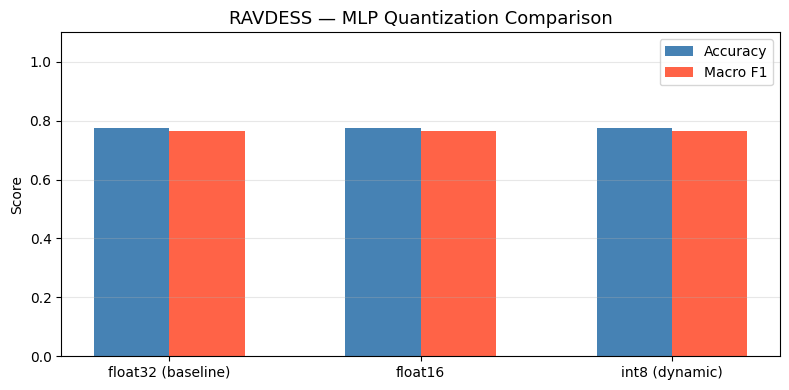

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3); width = 0.3
ax.bar(x - width/2, quant_df['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x + width/2, quant_df['Macro F1'], width, label='Macro F1', color='tomato')
ax.set_xticks(x); ax.set_xticklabels(quant_df['Precision'])
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('RAVDESS — MLP Quantization Comparison', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ravdess_quantization_results.png', dpi=150, bbox_inches='tight')
plt.show()

### 4C — Coreset Selection (Training Data Subsets)

In [18]:
coreset_rows = []

for frac in [1.0, 0.7, 0.5, 0.3]:
    if frac < 1.0:
        n = int(len(X_train_scaled) * frac)
        idx = np.random.RandomState(SEED).choice(len(X_train_scaled), n, replace=False)
        Xc, yc = X_train_scaled[idx], y_train[idx]
    else:
        Xc, yc = X_train_scaled, y_train

    cw_c = compute_class_weight('balanced', classes=np.unique(yc), y=yc)
    cl, tl = make_loaders(Xc, yc, X_test_scaled, y_test)
    torch.manual_seed(SEED)
    cm_ = MLP(INPUT_DIM, HIDDEN1, HIDDEN2, NUM_CLASSES, DROPOUT_RATE)
    train_mlp(cm_, cl, tl, verbose=False, class_weights=cw_c)

    cp = get_predictions(cm_, tl)
    ca, cf = accuracy_score(y_test, cp), f1_score(y_test, cp, average='macro')
    coreset_rows.append({'Fraction': f'{int(frac*100)}%', 'N (train)': len(Xc),
                         'Accuracy': ca, 'Macro F1': cf})
    print(f'Coreset {int(frac*100)}%  (n={len(Xc):,}):  Acc={ca:.4f}  F1={cf:.4f}')

coreset_df = pd.DataFrame(coreset_rows)
print('\nCoreset summary:')
print(coreset_df.to_string(index=False))

Coreset 100%  (n=1,152):  Acc=0.7743  F1=0.7662
Coreset 70%  (n=806):  Acc=0.7118  F1=0.7090
Coreset 50%  (n=576):  Acc=0.6806  F1=0.6760
Coreset 30%  (n=345):  Acc=0.6042  F1=0.5855

Coreset summary:
Fraction  N (train)  Accuracy  Macro F1
    100%       1152  0.774306  0.766181
     70%        806  0.711806  0.708987
     50%        576  0.680556  0.676014
     30%        345  0.604167  0.585541


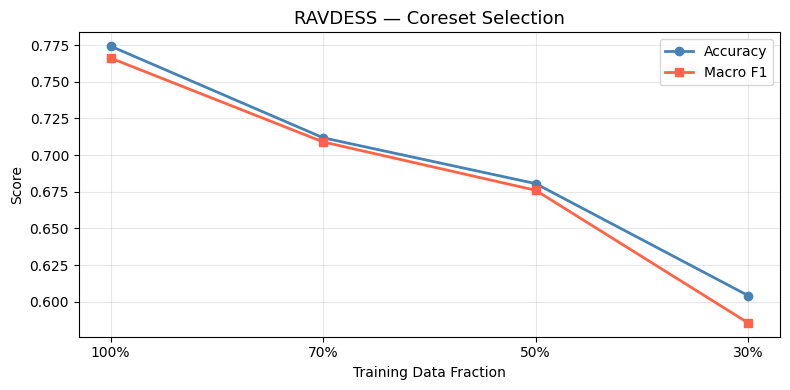

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(coreset_df['Fraction'], coreset_df['Accuracy'], 'o-', color='steelblue', lw=2, label='Accuracy')
ax.plot(coreset_df['Fraction'], coreset_df['Macro F1'], 's-', color='tomato', lw=2, label='Macro F1')
ax.set_title('RAVDESS — Coreset Selection', fontsize=13)
ax.set_xlabel('Training Data Fraction'); ax.set_ylabel('Score')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ravdess_coreset_results.png', dpi=150, bbox_inches='tight')
plt.show()

### 4D — Improvement 2: Combined Pruning + Quantization Strategy

**Why**: pruning and quantization attack model size from two different angles —
pruning removes redundant *connections*, quantization shrinks the *precision* of
the remaining ones. Applied together they compound: we take the GMP-pruned model
(40% sparsity) from Section 4A and additionally quantize it to float16 and int8,
then compare against each technique alone. The goal is to find the best
accuracy-vs-size trade-off.

In [20]:
# ── Pick the 50%-sparsity GMP model as the pruning stage ─────────────────────
COMBINE_RATIO = 0.4 if 0.4 in gmp_models else TARGET_RATIOS[1]
pruned_base = gmp_models[COMBINE_RATIO]
print(f'Using GMP model pruned to target ratio={COMBINE_RATIO:.0%} as the base for combination')

combo_rows = []

# 1) Baseline (no compression)
combo_rows.append({'Strategy': 'Baseline (dense, fp32)',
                   'Accuracy': mlp_acc, 'Macro F1': mlp_f1,
                   'Size (MB)': model_mb(mlp_model), 'Sparsity (%)': 0.0})

# 2) Pruning only (GMP, fp32)
pruned_preds = get_predictions(pruned_base, test_loader)
pruned_acc, pruned_f1 = accuracy_score(y_test, pruned_preds), f1_score(y_test, pruned_preds, average='macro')
combo_rows.append({'Strategy': f'GMP pruning only ({COMBINE_RATIO:.0%}, fp32)',
                   'Accuracy': pruned_acc, 'Macro F1': pruned_f1,
                   'Size (MB)': model_mb(pruned_base), 'Sparsity (%)': get_sparsity(pruned_base)})

# 3) Quantization only (no pruning, fp16 / int8)
combo_rows.append({'Strategy': 'Quantization only (fp16)',
                   'Accuracy': fp16_acc, 'Macro F1': fp16_f1,
                   'Size (MB)': model_mb(fp16_model), 'Sparsity (%)': 0.0})
combo_rows.append({'Strategy': 'Quantization only (int8)',
                   'Accuracy': int8_acc, 'Macro F1': int8_f1,
                   'Size (MB)': model_mb(mlp_model)/4, 'Sparsity (%)': 0.0})

# 4) Combined: GMP pruned model -> fp16
pruned_fp16 = to_fp16(pruned_base)
pf16_preds  = get_predictions_fp16(pruned_fp16, test_loader)
pf16_acc, pf16_f1 = accuracy_score(y_test, pf16_preds), f1_score(y_test, pf16_preds, average='macro')
combo_rows.append({'Strategy': f'GMP ({COMBINE_RATIO:.0%}) + fp16',
                   'Accuracy': pf16_acc, 'Macro F1': pf16_f1,
                   'Size (MB)': model_mb(pruned_fp16), 'Sparsity (%)': get_sparsity(pruned_base)})

# 5) Combined: GMP pruned model -> int8
pruned_int8 = to_int8(pruned_base)
pi8_preds   = get_predictions_int8(pruned_int8, test_loader)
pi8_acc, pi8_f1 = accuracy_score(y_test, pi8_preds), f1_score(y_test, pi8_preds, average='macro')
combo_rows.append({'Strategy': f'GMP ({COMBINE_RATIO:.0%}) + int8',
                   'Accuracy': pi8_acc, 'Macro F1': pi8_f1,
                   'Size (MB)': model_mb(pruned_base)/4, 'Sparsity (%)': get_sparsity(pruned_base)})

combo_df = pd.DataFrame(combo_rows)
combo_df['Compression Ratio'] = (combo_df['Size (MB)'].iloc[0] / combo_df['Size (MB)']).round(2)
print('=' * 85)
print('COMBINED PRUNING + QUANTIZATION COMPARISON')
print('=' * 85)
print(combo_df.to_string(index=False))

Using GMP model pruned to target ratio=40% as the base for combination
COMBINED PRUNING + QUANTIZATION COMPARISON
                    Strategy  Accuracy  Macro F1  Size (MB)  Sparsity (%)  Compression Ratio
      Baseline (dense, fp32)  0.774306  0.766181   0.078112      0.000000                1.0
GMP pruning only (40%, fp32)  0.756944  0.750701   0.078112     40.002111                1.0
    Quantization only (fp16)  0.774306  0.766181   0.039056      0.000000                2.0
    Quantization only (int8)  0.774306  0.764746   0.019528      0.000000                4.0
            GMP (40%) + fp16  0.756944  0.750701   0.039056     40.002111                2.0
            GMP (40%) + int8  0.750000  0.741007   0.019528     40.002111                4.0


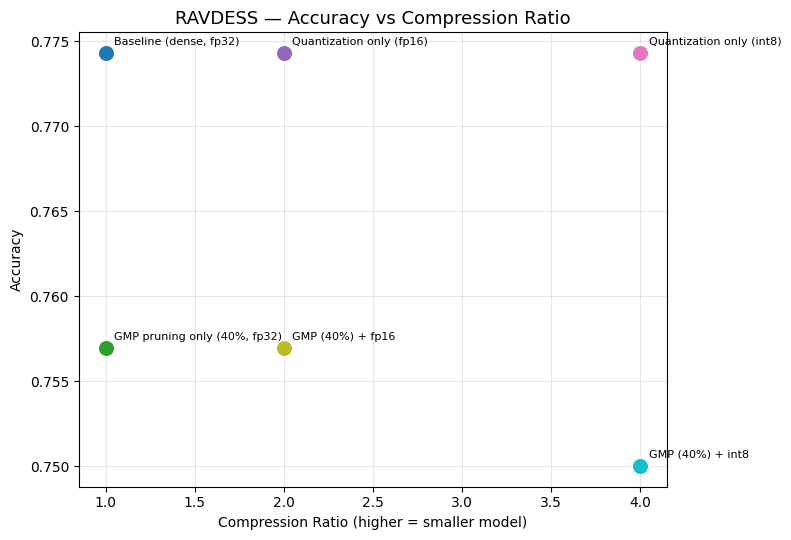

Saved: ravdess_combined_pruning_quant.png  ravdess_combined_pruning_quant.csv


In [21]:
# ── Accuracy vs Compression Ratio scatter ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = plt.cm.tab10(np.linspace(0, 1, len(combo_df)))
for i, row in combo_df.iterrows():
    ax.scatter(row['Compression Ratio'], row['Accuracy'], s=140,
               color=colors[i], edgecolor='white', zorder=3)
    ax.annotate(row['Strategy'], (row['Compression Ratio'], row['Accuracy']),
                textcoords='offset points', xytext=(6, 6), fontsize=8)

ax.set_xlabel('Compression Ratio (higher = smaller model)')
ax.set_ylabel('Accuracy')
ax.set_title('RAVDESS — Accuracy vs Compression Ratio', fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ravdess_combined_pruning_quant.png', dpi=150, bbox_inches='tight')
plt.show()
combo_df.to_csv('ravdess_combined_pruning_quant.csv', index=False)
print('Saved: ravdess_combined_pruning_quant.png  ravdess_combined_pruning_quant.csv')

In [22]:
## 4E — Improvement 3: K-Means Diversity-Based Coreset vs Random Coreset
#
# Random sampling can over/under-represent regions of the feature space by chance.
# K-Means coreset selection clusters each class into k groups and picks the sample
# nearest each centroid, ensuring the subset is diverse and representative.

from sklearn.cluster import KMeans

def kmeans_coreset_indices(X, y, fraction, seed=SEED):
    """For each class, cluster into k=ceil(fraction * n_class) groups and
    select the real sample closest to each centroid."""
    selected_idx = []
    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        n_cls = len(cls_idx)
        k = max(1, int(np.ceil(n_cls * fraction)))
        if k >= n_cls:
            selected_idx.extend(cls_idx.tolist())
            continue
        X_cls = X[cls_idx]
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        km.fit(X_cls)
        for c in range(k):
            cluster_points = np.where(km.labels_ == c)[0]
            if len(cluster_points) == 0:
                continue
            center = km.cluster_centers_[c]
            dists  = np.linalg.norm(X_cls[cluster_points] - center, axis=1)
            closest = cluster_points[np.argmin(dists)]
            selected_idx.append(cls_idx[closest])
    return np.array(selected_idx)


kmeans_coreset_rows = []

for frac in [0.3, 0.5, 0.7]:
    # Random coreset (same as 4C, for direct comparison)
    n = int(len(X_train_scaled) * frac)
    rand_idx = np.random.RandomState(SEED).choice(len(X_train_scaled), n, replace=False)
    Xr, yr = X_train_scaled[rand_idx], y_train[rand_idx]

    # K-Means diversity coreset
    km_idx = kmeans_coreset_indices(X_train_scaled, y_train, frac)
    Xk, yk = X_train_scaled[km_idx], y_train[km_idx]

    for label, (Xc, yc) in [('Random', (Xr, yr)), ('K-Means', (Xk, yk))]:
        cw_c = compute_class_weight('balanced', classes=np.unique(yc), y=yc)
        cl, tl = make_loaders(Xc, yc, X_test_scaled, y_test)
        torch.manual_seed(SEED)
        cm_ = MLP(INPUT_DIM, HIDDEN1, HIDDEN2, NUM_CLASSES, DROPOUT_RATE)
        train_mlp(cm_, cl, tl, verbose=False, class_weights=cw_c)
        cp = get_predictions(cm_, tl)
        ca = accuracy_score(y_test, cp)
        cf = f1_score(y_test, cp, average='macro')
        kmeans_coreset_rows.append({'Fraction': f'{int(frac*100)}%', 'Method': label,
                                     'N (train)': len(Xc), 'Accuracy': ca, 'Macro F1': cf})
        print(f'{label:10s} {int(frac*100)}%  (n={len(Xc):,}):  Acc={ca:.4f}  F1={cf:.4f}')

kmeans_coreset_df = pd.DataFrame(kmeans_coreset_rows)
print('\nK-Means vs Random Coreset:')
print(kmeans_coreset_df.to_string(index=False))

Random     30%  (n=345):  Acc=0.6042  F1=0.5855
K-Means    30%  (n=350):  Acc=0.6042  F1=0.5997
Random     50%  (n=576):  Acc=0.6806  F1=0.6760
K-Means    50%  (n=578):  Acc=0.6910  F1=0.6858
Random     70%  (n=806):  Acc=0.7118  F1=0.7090
K-Means    70%  (n=810):  Acc=0.7604  F1=0.7567

K-Means vs Random Coreset:
Fraction  Method  N (train)  Accuracy  Macro F1
     30%  Random        345  0.604167  0.585541
     30% K-Means        350  0.604167  0.599686
     50%  Random        576  0.680556  0.676014
     50% K-Means        578  0.690972  0.685806
     70%  Random        806  0.711806  0.708987
     70% K-Means        810  0.760417  0.756709


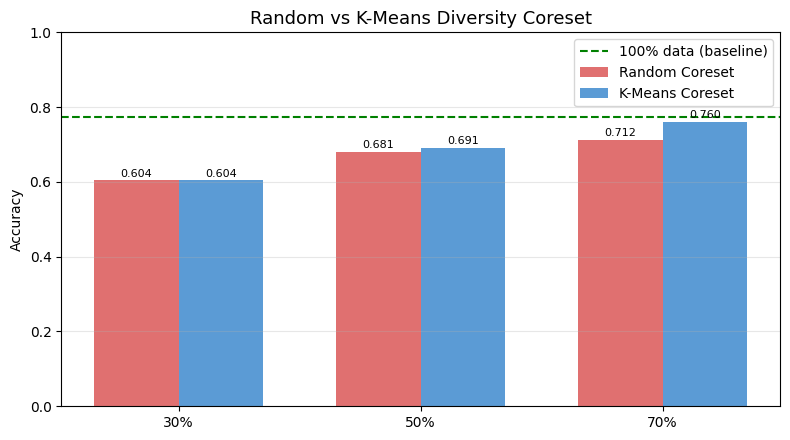

Saved: ravdess_kmeans_coreset_comparison.png/.csv


In [25]:
# ── Plot: Random vs K-Means coreset accuracy at each fraction ────────────────
pivot_acc = kmeans_coreset_df.pivot(index='Fraction', columns='Method', values='Accuracy')
pivot_acc = pivot_acc.reindex(['30%', '50%', '70%'])

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(pivot_acc)); width = 0.35
ax.bar(x - width/2, pivot_acc['Random'],  width, label='Random Coreset',  color='#e07070')
ax.bar(x + width/2, pivot_acc['K-Means'], width, label='K-Means Coreset', color='#5b9bd5')
ax.axhline(mlp_acc, ls='--', color='green', lw=1.5, label='100% data (baseline)')
ax.set_xticks(x); ax.set_xticklabels(pivot_acc.index)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.0)
ax.set_title('Random vs K-Means Diversity Coreset', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.3)
for i, frac_idx in enumerate(pivot_acc.index):
    ax.text(i - width/2, pivot_acc.loc[frac_idx, 'Random']  + 0.01, f"{pivot_acc.loc[frac_idx,'Random']:.3f}",  ha='center', fontsize=8)
    ax.text(i + width/2, pivot_acc.loc[frac_idx, 'K-Means'] + 0.01, f"{pivot_acc.loc[frac_idx,'K-Means']:.3f}", ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(f'{PREFIX}kmeans_coreset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
kmeans_coreset_df.to_csv(f'{PREFIX}kmeans_coreset_comparison.csv', index=False)
print(f'Saved: {PREFIX}kmeans_coreset_comparison.png/.csv')

## 📊 Section 5 — Final Results Table & Comparison

Computing one-shot pruned model...
Training coreset models at 50% of training data...
  Random Coreset (50%):  Acc=0.6806  F1=0.6760
  K-Means Coreset (50%): Acc=0.6910  F1=0.6858

  K-Means improvement over Random: +0.0104 accuracy
COMPREHENSIVE METRICS TABLE — RAVDESS
                      Model  Accuracy  Macro F1  Macro Precision  Macro Recall    MSE
        SVM (RBF, balanced)    0.8229    0.8152           0.8197        0.8148 1.7986
   Random Forest (balanced)    0.6424    0.6389           0.6771        0.6319 4.3160
             MLP (baseline)    0.7743    0.7662           0.7783        0.7621 3.0382
 MLP + One-Shot Prune (40%)    0.7361    0.7239           0.7310        0.7233 3.3576
            MLP + GMP (40%)    0.7569    0.7507           0.7543        0.7493 2.8924
           MLP + int8 quant    0.7743    0.7647           0.7734        0.7621 2.9306
     MLP + GMP (40%) + int8    0.7500    0.7410           0.7448        0.7395 2.8438
 MLP + Random Coreset (50%)    0.6806    

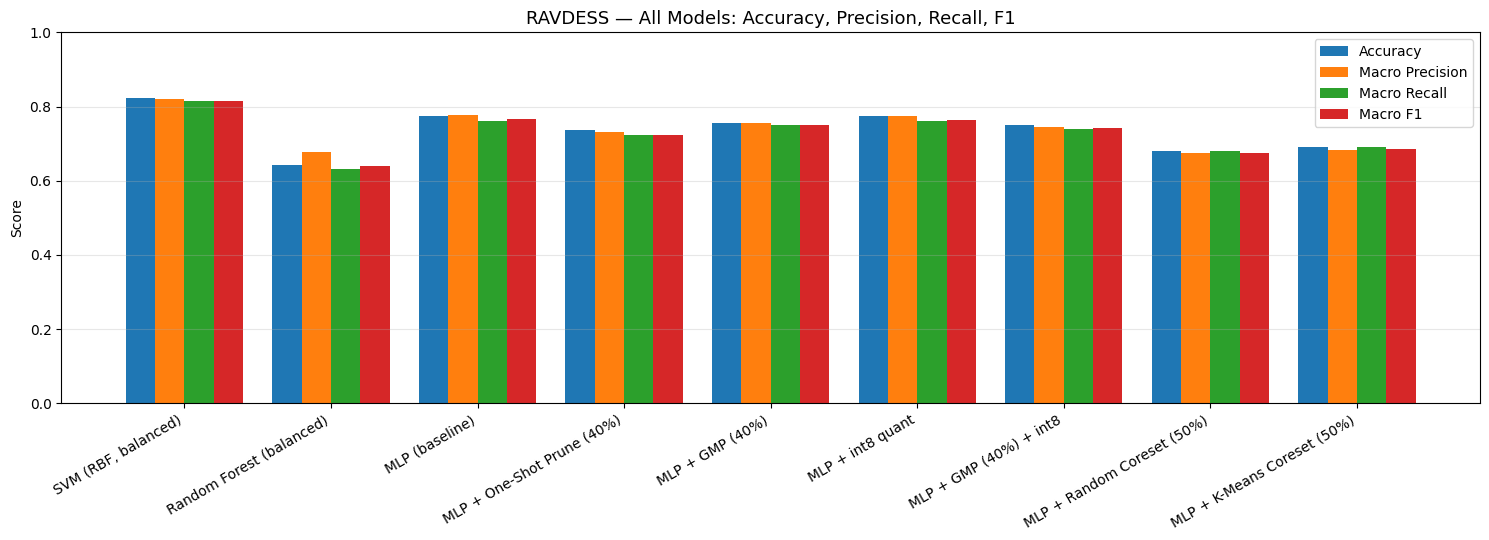

Saved: ravdess_all_metrics_comparison.png


In [26]:
## Comprehensive Metrics Table — All Models (Accuracy, Macro F1, Precision, Recall, MSE)

PREFIX       = 'ravdess_'      # or 'ravdess_' for the other notebook
DATASET_NAME = 'RAVDESS'      # or 'RAVDESS'

from sklearn.cluster import KMeans
from sklearn.metrics import precision_score, recall_score

# ── Re-define K-Means coreset selector (safe to redefine) ────────────────────
def kmeans_coreset_indices(X, y, fraction, seed=SEED):
    """For each class, cluster into k=ceil(fraction * n_class) groups and
    select the real sample closest to each centroid."""
    selected_idx = []
    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        n_cls = len(cls_idx)
        k = max(1, int(np.ceil(n_cls * fraction)))
        if k >= n_cls:
            selected_idx.extend(cls_idx.tolist())
            continue
        X_cls = X[cls_idx]
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        km.fit(X_cls)
        for c in range(k):
            cluster_points = np.where(km.labels_ == c)[0]
            if len(cluster_points) == 0:
                continue
            center = km.cluster_centers_[c]
            dists  = np.linalg.norm(X_cls[cluster_points] - center, axis=1)
            closest = cluster_points[np.argmin(dists)]
            selected_idx.append(cls_idx[closest])
    return np.array(selected_idx)


# ── Safety check: one-shot pruned predictions ────────────────────────────────
if 'oneshot_preds' not in globals():
    print('Computing one-shot pruned model...')
    oneshot_pruned_model = copy.deepcopy(mlp_model)
    apply_magnitude_mask(oneshot_pruned_model, COMBINE_RATIO)
    oneshot_preds = get_predictions(oneshot_pruned_model, test_loader)
    oneshot_acc = accuracy_score(y_test, oneshot_preds)
    oneshot_f1  = f1_score(y_test, oneshot_preds, average='macro')

# ── Safety check / compute: Random vs K-Means coreset models ─────────────────
CORESET_FRACTION = 0.5

if 'kmeans_coreset_preds' not in globals() or 'random_coreset_preds' not in globals():
    print(f'Training coreset models at {CORESET_FRACTION:.0%} of training data...')
    n = int(len(X_train_scaled) * CORESET_FRACTION)

    # Random coreset
    rand_idx = np.random.RandomState(SEED).choice(len(X_train_scaled), n, replace=False)
    Xr, yr = X_train_scaled[rand_idx], y_train[rand_idx]
    cw_r = compute_class_weight('balanced', classes=np.unique(yr), y=yr)
    rl, rtl = make_loaders(Xr, yr, X_test_scaled, y_test)
    torch.manual_seed(SEED)
    random_coreset_model = MLP(INPUT_DIM, HIDDEN1, HIDDEN2, NUM_CLASSES, DROPOUT_RATE)
    train_mlp(random_coreset_model, rl, rtl, verbose=False, class_weights=cw_r)
    random_coreset_preds = get_predictions(random_coreset_model, rtl)
    random_coreset_acc = accuracy_score(y_test, random_coreset_preds)
    random_coreset_f1  = f1_score(y_test, random_coreset_preds, average='macro')
    print(f'  Random Coreset ({CORESET_FRACTION:.0%}):  Acc={random_coreset_acc:.4f}  F1={random_coreset_f1:.4f}')

    # K-Means coreset
    km_idx = kmeans_coreset_indices(X_train_scaled, y_train, CORESET_FRACTION)
    Xk, yk = X_train_scaled[km_idx], y_train[km_idx]
    cw_k = compute_class_weight('balanced', classes=np.unique(yk), y=yk)
    kl, ktl = make_loaders(Xk, yk, X_test_scaled, y_test)
    torch.manual_seed(SEED)
    kmeans_coreset_model = MLP(INPUT_DIM, HIDDEN1, HIDDEN2, NUM_CLASSES, DROPOUT_RATE)
    train_mlp(kmeans_coreset_model, kl, ktl, verbose=False, class_weights=cw_k)
    kmeans_coreset_preds = get_predictions(kmeans_coreset_model, ktl)
    kmeans_coreset_acc = accuracy_score(y_test, kmeans_coreset_preds)
    kmeans_coreset_f1  = f1_score(y_test, kmeans_coreset_preds, average='macro')
    print(f'  K-Means Coreset ({CORESET_FRACTION:.0%}): Acc={kmeans_coreset_acc:.4f}  F1={kmeans_coreset_f1:.4f}')
    print(f'\n  K-Means improvement over Random: {kmeans_coreset_acc - random_coreset_acc:+.4f} accuracy')


def compute_all_metrics(name, y_true, preds):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, preds),
        'Macro F1': f1_score(y_true, preds, average='macro'),
        'Macro Precision': precision_score(y_true, preds, average='macro', zero_division=0),
        'Macro Recall': recall_score(y_true, preds, average='macro', zero_division=0),
        'MSE': mean_squared_error(y_true, preds),
    }

all_metrics_rows = []

for r in results[:2]:
    all_metrics_rows.append(compute_all_metrics(r['Model'], y_test, r['predictions']))

all_metrics_rows.append(compute_all_metrics('MLP (baseline)', y_test, mlp_preds))
all_metrics_rows.append(compute_all_metrics(
    f'MLP + One-Shot Prune ({COMBINE_RATIO:.0%})', y_test, oneshot_preds))
all_metrics_rows.append(compute_all_metrics(
    f'MLP + GMP ({COMBINE_RATIO:.0%})', y_test, pruned_preds))
all_metrics_rows.append(compute_all_metrics('MLP + int8 quant', y_test, int8_preds))
all_metrics_rows.append(compute_all_metrics(
    f'MLP + GMP ({COMBINE_RATIO:.0%}) + int8', y_test, pi8_preds))
all_metrics_rows.append(compute_all_metrics(
    f'MLP + Random Coreset ({CORESET_FRACTION:.0%})', y_test, random_coreset_preds))
all_metrics_rows.append(compute_all_metrics(
    f'MLP + K-Means Coreset ({CORESET_FRACTION:.0%})', y_test, kmeans_coreset_preds))

all_metrics_df = pd.DataFrame(all_metrics_rows).round(4)

print('=' * 95)
print(f'COMPREHENSIVE METRICS TABLE — {DATASET_NAME}')
print('=' * 95)
print(all_metrics_df.to_string(index=False))

all_metrics_df.to_csv(f'{PREFIX}all_metrics_table.csv', index=False)
print(f'\nSaved: {PREFIX}all_metrics_table.csv')

# ── Grouped bar chart: Accuracy / Precision / Recall / F1 ────────────────────
fig, ax = plt.subplots(figsize=(15, 5.5))
metrics_to_plot = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
x = np.arange(len(all_metrics_df))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    offset = (i - 1.5) * width
    ax.bar(x + offset, all_metrics_df[metric], width, label=metric)

ax.set_xticks(x)
ax.set_xticklabels(all_metrics_df['Model'], rotation=30, ha='right')
ax.set_ylim(0, 1.0); ax.set_ylabel('Score')
ax.set_title(f'{DATASET_NAME} — All Models: Accuracy, Precision, Recall, F1', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PREFIX}all_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PREFIX}all_metrics_comparison.png')

In [27]:
# ── One-shot pruned model at the same ratio as GMP, for fair comparison ──────
oneshot_pruned_model = copy.deepcopy(mlp_model)
apply_magnitude_mask(oneshot_pruned_model, COMBINE_RATIO)
oneshot_preds = get_predictions(oneshot_pruned_model, test_loader)
oneshot_acc = accuracy_score(y_test, oneshot_preds)
oneshot_f1  = f1_score(y_test, oneshot_preds, average='macro')

final_rows = []
for r in results:
    final_rows.append({'Model': r['Model'], 'Accuracy': r['Accuracy'],
                       'Macro F1': r['Macro F1'], 'MSE': r['MSE']})

final_rows.append({'Model': 'MLP (baseline)',
                   'Accuracy': mlp_acc, 'Macro F1': mlp_f1,
                   'MSE': mlp_mse})
final_rows.append({'Model': f'MLP + One-Shot Prune ({COMBINE_RATIO:.0%})',
                   'Accuracy': oneshot_acc, 'Macro F1': oneshot_f1,
                   'MSE': mean_squared_error(y_test, oneshot_preds)})
final_rows.append({'Model': f'MLP + GMP ({COMBINE_RATIO:.0%} sparse)',
                   'Accuracy': pruned_acc, 'Macro F1': pruned_f1,
                   'MSE': mean_squared_error(y_test, pruned_preds)})
final_rows.append({'Model': 'MLP + int8 quant',
                   'Accuracy': int8_acc, 'Macro F1': int8_f1,
                   'MSE': mean_squared_error(y_test, int8_preds)})
final_rows.append({'Model': f'MLP + GMP ({COMBINE_RATIO:.0%}) + int8',
                   'Accuracy': pi8_acc, 'Macro F1': pi8_f1,
                   'MSE': mean_squared_error(y_test, pi8_preds)})
final_rows.append({'Model': f'MLP + Random Coreset ({CORESET_FRACTION:.0%})',
                   'Accuracy': random_coreset_acc, 'Macro F1': random_coreset_f1,
                   'MSE': mean_squared_error(y_test, random_coreset_preds)})
final_rows.append({'Model': f'MLP + K-Means Coreset ({CORESET_FRACTION:.0%})',
                   'Accuracy': kmeans_coreset_acc, 'Macro F1': kmeans_coreset_f1,
                   'MSE': mean_squared_error(y_test, kmeans_coreset_preds)})

final_df = pd.DataFrame(final_rows)
print('=' * 75)
print(f'FINAL RESULTS — {DATASET_NAME}')
print('=' * 75)
print(final_df.to_string(index=False))
final_df.to_csv(f'{PREFIX}final_results.csv', index=False)
print(f'\nSaved: {PREFIX}final_results.csv')

print(f'\nAt {COMBINE_RATIO:.0%} sparsity:')
print(f'  One-Shot Pruning : Acc={oneshot_acc:.4f}  F1={oneshot_f1:.4f}')
print(f'  Gradual (GMP)    : Acc={pruned_acc:.4f}  F1={pruned_f1:.4f}')
print(f'  GMP improvement  : {pruned_acc - oneshot_acc:+.4f} accuracy')

print(f'\nAt {CORESET_FRACTION:.0%} training data:')
print(f'  Random Coreset   : Acc={random_coreset_acc:.4f}  F1={random_coreset_f1:.4f}')
print(f'  K-Means Coreset  : Acc={kmeans_coreset_acc:.4f}  F1={kmeans_coreset_f1:.4f}')
print(f'  K-Means improvement : {kmeans_coreset_acc - random_coreset_acc:+.4f} accuracy')

FINAL RESULTS — RAVDESS
                      Model  Accuracy  Macro F1      MSE
        SVM (RBF, balanced)  0.822917  0.815166 1.798611
   Random Forest (balanced)  0.642361  0.638945 4.315972
             MLP (baseline)  0.774306  0.766181 3.038194
             MLP (baseline)  0.774306  0.766181 3.038194
 MLP + One-Shot Prune (40%)  0.736111  0.723871 3.357639
     MLP + GMP (40% sparse)  0.756944  0.750701 2.892361
           MLP + int8 quant  0.774306  0.764746 2.930556
     MLP + GMP (40%) + int8  0.750000  0.741007 2.843750
 MLP + Random Coreset (50%)  0.680556  0.676014 4.336806
MLP + K-Means Coreset (50%)  0.690972  0.685806 4.114583

Saved: ravdess_final_results.csv

At 40% sparsity:
  One-Shot Pruning : Acc=0.7361  F1=0.7239
  Gradual (GMP)    : Acc=0.7569  F1=0.7507
  GMP improvement  : +0.0208 accuracy

At 50% training data:
  Random Coreset   : Acc=0.6806  F1=0.6760
  K-Means Coreset  : Acc=0.6910  F1=0.6858
  K-Means improvement : +0.0104 accuracy


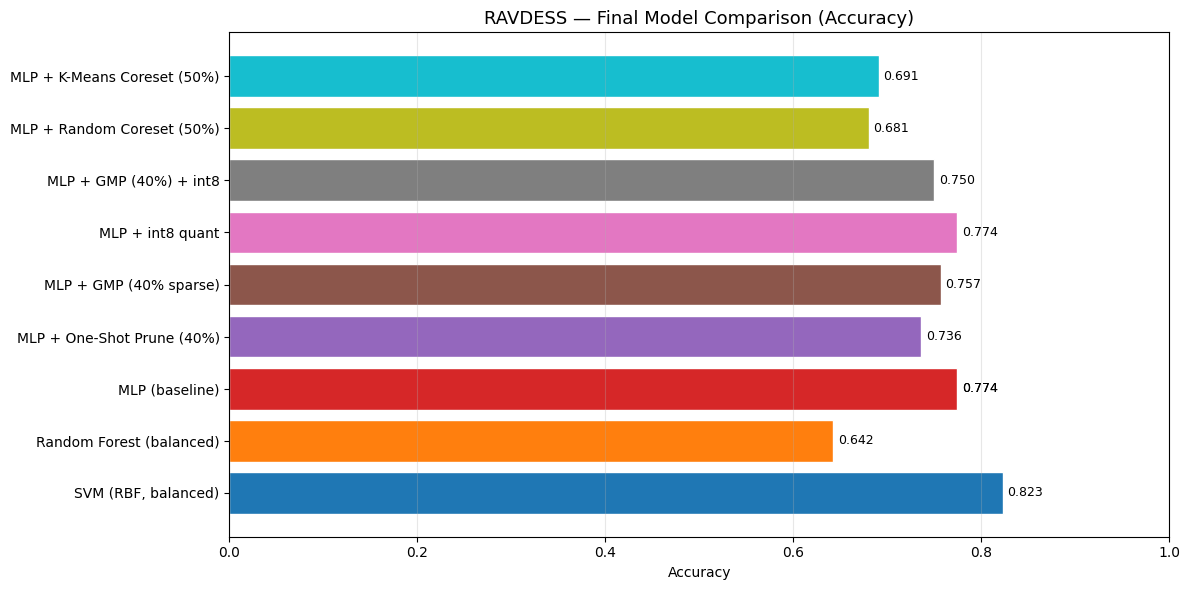

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(final_df)))
bars = ax.barh(final_df['Model'], final_df['Accuracy'], color=colors, edgecolor='white')
ax.set_xlim(0, 1.0); ax.set_xlabel('Accuracy')
ax.set_title(f'{DATASET_NAME} — Final Model Comparison (Accuracy)', fontsize=13)
for bar, val in zip(bars, final_df['Accuracy']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PREFIX}final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

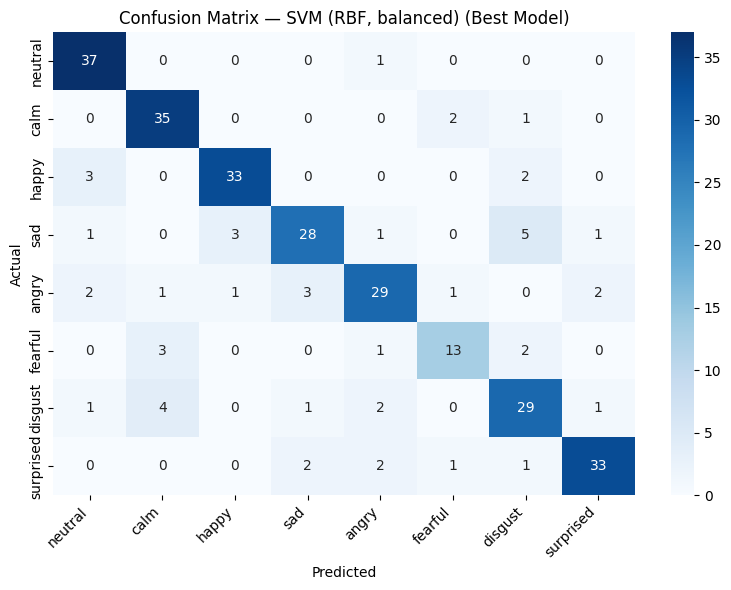

Best model: SVM (RBF, balanced)  (Acc=0.8229)


In [29]:
best_idx = final_df['Accuracy'].idxmax()
best_name = final_df.loc[best_idx, 'Model']

pred_lookup = {
    **{r['Model']: r['predictions'] for r in results},
    'MLP (baseline)': mlp_preds,
    f'MLP + One-Shot Prune ({COMBINE_RATIO:.0%})': oneshot_preds,
    f'MLP + GMP ({COMBINE_RATIO:.0%} sparse)': pruned_preds,
    'MLP + int8 quant': int8_preds,
    f'MLP + GMP ({COMBINE_RATIO:.0%}) + int8': pi8_preds,
    f'MLP + Random Coreset ({CORESET_FRACTION:.0%})': random_coreset_preds,
    f'MLP + K-Means Coreset ({CORESET_FRACTION:.0%})': kmeans_coreset_preds,
}
best_preds = pred_lookup[best_name]

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS)
ax.set_title(f'Confusion Matrix — {best_name} (Best Model)', fontsize=12)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{PREFIX}best_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best model: {best_name}  (Acc={final_df.loc[best_idx, "Accuracy"]:.4f})')

## 🗂️ Section 6 — Summary & Saved Outputs

In [30]:
torch.save(mlp_model.state_dict(), f'{PREFIX}mlp_model.pth')
torch.save(pruned_base.state_dict(), f'{PREFIX}mlp_gmp_pruned.pth')

print('=' * 65)
print(f'NEW DELIVERABLE — {DATASET_NAME} — COMPLETED ✅')
print('=' * 65)
print('Top-2 classical models:')
for r in top2:
    print(f"  ✅ {r['Model']}  (Acc={r['Accuracy']:.4f})")
print(f'\nMLP baseline                     : Acc={mlp_acc:.4f}  F1={mlp_f1:.4f}')
print(f'MLP + One-Shot Prune ({COMBINE_RATIO:.0%})       : Acc={oneshot_acc:.4f}  F1={oneshot_f1:.4f}')
print(f'MLP + GMP ({COMBINE_RATIO:.0%})                  : Acc={pruned_acc:.4f}  F1={pruned_f1:.4f}')
print(f'MLP + int8                       : Acc={int8_acc:.4f}  F1={int8_f1:.4f}')
print(f'MLP + GMP + int8                 : Acc={pi8_acc:.4f}  F1={pi8_f1:.4f}')
print(f'MLP + Random Coreset ({CORESET_FRACTION:.0%})    : Acc={random_coreset_acc:.4f}  F1={random_coreset_f1:.4f}')
print(f'MLP + K-Means Coreset ({CORESET_FRACTION:.0%})   : Acc={kmeans_coreset_acc:.4f}  F1={kmeans_coreset_f1:.4f}')
print(f'\nBest model overall : {best_name}')

print('\nFiles saved:')
for fn in ['final_results.csv', 'final_comparison.png', 'best_confusion_matrix.png',
           'mlp_training_curves.png', 'gmp_comparison.png', 'gmp_comparison.csv',
           'quantization_results.png', 'coreset_results.png',
           'combined_pruning_quant.png', 'combined_pruning_quant.csv',
           'kmeans_coreset_comparison.png', 'kmeans_coreset_comparison.csv',
           'all_metrics_table.csv', 'all_metrics_comparison.png',
           'mlp_model.pth', 'mlp_gmp_pruned.pth']:
    print(f'  ✅ {PREFIX}{fn}')

NEW DELIVERABLE — RAVDESS — COMPLETED ✅
Top-2 classical models:
  ✅ SVM (RBF, balanced)  (Acc=0.8229)
  ✅ Random Forest (balanced)  (Acc=0.6424)

MLP baseline                     : Acc=0.7743  F1=0.7662
MLP + One-Shot Prune (40%)       : Acc=0.7361  F1=0.7239
MLP + GMP (40%)                  : Acc=0.7569  F1=0.7507
MLP + int8                       : Acc=0.7743  F1=0.7647
MLP + GMP + int8                 : Acc=0.7500  F1=0.7410
MLP + Random Coreset (50%)    : Acc=0.6806  F1=0.6760
MLP + K-Means Coreset (50%)   : Acc=0.6910  F1=0.6858

Best model overall : SVM (RBF, balanced)

Files saved:
  ✅ ravdess_final_results.csv
  ✅ ravdess_final_comparison.png
  ✅ ravdess_best_confusion_matrix.png
  ✅ ravdess_mlp_training_curves.png
  ✅ ravdess_gmp_comparison.png
  ✅ ravdess_gmp_comparison.csv
  ✅ ravdess_quantization_results.png
  ✅ ravdess_coreset_results.png
  ✅ ravdess_combined_pruning_quant.png
  ✅ ravdess_combined_pruning_quant.csv
  ✅ ravdess_kmeans_coreset_comparison.png
  ✅ ravdess_kmean